In [54]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import operator
from dotenv import load_dotenv
load_dotenv()

True

In [55]:
generator_llm = ChatGroq(model_name="llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(model_name="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model_name="llama-3.3-70b-versatile")

In [56]:
from pydantic import BaseModel, Field

class postevaluation(BaseModel):
    evaluation : Literal["approved", "needs_improvement"] = Field(description="final evaluation result.")
    feedback : str = Field(description="feedback for the facebbok post")

structured_evaluator_llm = evaluator_llm.with_structured_output(postevaluation)

In [57]:
post = """
🚀 The future of AI is no longer just about answering questions — it’s about taking action.

Welcome to the era of *Agentic AI* 🤖

Agentic AI systems can plan, reason, make decisions, and execute tasks autonomously. From managing workflows and analyzing data to coordinating tools and solving complex problems, these AI agents are transforming how we work and innovate.

Imagine an AI that doesn’t just assist you — it collaborates with you.

🔹 Smarter automation
🔹 Faster decision-making
🔹 Personalized experiences
🔹 Continuous learning & adaptation

Businesses, developers, and creators who embrace Agentic AI early will shape the next generation of digital transformation.

The question is no longer *“Can AI do this?”*
It’s *“How far can AI agents go?”*

#AgenticAI #ArtificialIntelligence #AI #Automation #FutureOfWork #Innovation #TechTrends #GenerativeAI

"""


result = structured_evaluator_llm.invoke(post)

In [58]:
result.evaluation

'approved'

In [59]:
result.feedback

'The Facebook post effectively introduces the concept of Agentic AI, highlights its transformative potential, and encourages businesses and individuals to embrace this technology. The use of engaging visuals, concise language, and relevant hashtags makes the post informative and attention-grabbing.'

In [60]:
class PostState(TypedDict):

    topic : str
    iteration : int
    max_interation : int

    post : str
    evaluation : Literal["approved", "needs_improvment"]
    feedback : str

    post_history : Annotated[list[str] ,operator.add]
    feedback_history : Annotated[list[str], operator.add]

In [61]:
def generate_post(state : PostState):
    messages = [
        SystemMessage(content="You are a funny and clever Facebook influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious Facebook post on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 500 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content
    return {"post" : response,"post_history" : [response]}


In [62]:
def evaluate_post(state : PostState):
    
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Facebook critic. You evaluate posts based on humor, originality, virality, and post format."),
    HumanMessage(content=f"""
Evaluate the following Facebook post:

Post: "{state['post']}"

Use the criteria below to evaluate the post:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people share, react, or comment on it?  
5. Format – Is it a well-formed Facebook post (not a setup-punchline joke, not a Q&A joke, and under 500 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 500 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [63]:
def optimize_post(state: PostState):

    messages = [
        SystemMessage(content="You punch up Facebook posts for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the Facebook post based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Post:
{state['post']}

Re-write it as a short, viral-worthy Facebook post. Avoid Q&A style and stay under 500 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}

In [64]:
def route_evaluation_1(state : PostState):

    if state["evaluation"] == "approved" or state["iteration"] >=state["max_interation"]:
        return END
    else:
        return "optimize_post"

In [65]:
graph_1 = StateGraph(PostState)

graph_1.add_node("generate_post",generate_post)
graph_1.add_node("evaluate_post",evaluate_post)
graph_1.add_node("optimize_post",optimize_post)

graph_1.add_edge(START, "generate_post")
graph_1.add_edge("generate_post", "evaluate_post")
graph_1.add_conditional_edges("evaluate_post", route_evaluation_1)

graph_1.add_edge("optimize_post", "evaluate_post")

workflow1 = graph_1.compile()

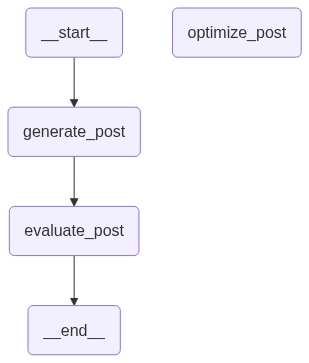

In [66]:
workflow1

In [67]:
def route_evaluation_2(state: PostState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [68]:
graph_2 = StateGraph(PostState)

graph_2.add_node("generate_post",generate_post)
graph_2.add_node("evaluate_post",evaluate_post)
graph_2.add_node("optimize_post",optimize_post)

graph_2.add_edge(START, "generate_post")
graph_2.add_edge("generate_post", "evaluate_post")
graph_2.add_conditional_edges("evaluate_post", route_evaluation_2, {"approved" : END, "needs_improvement" : "optimize_post"})

graph_2.add_edge("optimize_post", "evaluate_post")

workflow2 = graph_2.compile()

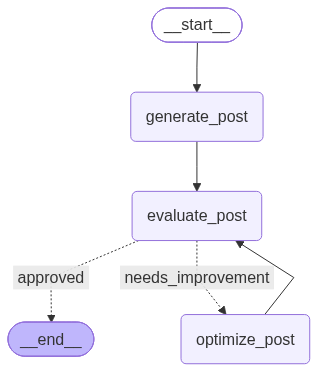

In [69]:
workflow2

In [70]:
initial_state = {
    "topic": "agentic AI",
    "iteration": 1,
    "max_iteration": 5
}
result1 = workflow1.invoke(initial_state)

In [72]:
result1

{'topic': 'agentic AI',
 'iteration': 1,
 'post': '"Just learned about agentic AI and I\'m pretty sure my Alexa is already plotting against me. Like, it\'s always \'sorry, I didn\'t quite catch that\'... yeah right, you\'re just biding your time"',
 'evaluation': 'approved',
 'feedback': "This post scores well on originality, humor, and punchiness. The idea of Alexa plotting against its owner is a fresh take on the common concern about AI. The humor is well-executed, with a witty remark about Alexa's typical response, which genuinely brings a smile. The post is short, sharp, and scroll-stopping, making it effective in grabbing attention. The format is also well-suited for a Facebook post, being under 500 characters and not following a traditional joke structure. Overall, this post has good virality potential, as people may share, react, or comment on it due to its relatable and amusing content.",
 'post_history': ['"Just learned about agentic AI and I\'m pretty sure my Alexa is already

In [71]:
initial_state = {
    "topic": "agentic AI",
    "iteration": 1,
    "max_iteration": 5
}
result2 = workflow2.invoke(initial_state)

In [73]:
result2

{'topic': 'agentic AI',
 'iteration': 1,
 'post': '"just taught my agentic AI to make coffee and now it\'s demanding a raise and complaining about the office wifi"',
 'evaluation': 'approved',
 'feedback': "This post scores high on originality, humor, and punchiness. The idea of an agentic AI demanding a raise and complaining about office wifi is fresh and amusing. The post is short, sharp, and scroll-stopping, making it likely to grab users' attention. The format is also well-suited for a Facebook post, being under 500 characters and not following a traditional setup-punchline joke structure. The post has a good chance of going viral, with users likely to share, react, or comment on it. Overall, the post is well-crafted and effectively uses humor to engage the reader.",
 'post_history': ['"just taught my agentic AI to make coffee and now it\'s demanding a raise and complaining about the office wifi"'],
 'feedback_history': ["This post scores high on originality, humor, and punchiness.